<h1 align="center"> Inference </h1>

Finds ultrasound image and RNA-seq embeddings, and diagnosis. Final datasets exported to master DataFrames.

<br>
<i> Import necessary libraries: <i>

In [1]:
# Additional imports needed to load src.model and src.dataset
import sys
sys.path.append("..")

import os
os.environ["NO_ALBUMENTATIONS_UPDATE"] = "1"
import torch
import pandas as pd
import torch.optim as optim
from torchvision import transforms
from torch.utils.data import DataLoader
from src.model import CLIPModel, RNAEncoder, ImageEncoder, ContrastiveLoss
from src.dataset import RNACustomDataset, ImgCustomDataset
from sklearn.model_selection import train_test_split
import torch.nn as nn 
import numpy as np
import albumentations as albu # For image augmentations
import cv2
from albumentations.pytorch import ToTensorV2
from src.optimise import set_seed, calc_mean_std, generate_model_name
from sklearn.preprocessing import StandardScaler
from sklearn import preprocessing

from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from scipy.stats import spearmanr
np.random.seed(2)

# Set random seed for weights
random_seed = 2
set_seed(random_seed)

Random seed set as 2


### Load Data

In [2]:
# Step 1: Load RNA-Seq data
df_rna = pd.read_csv("/home/kryan24/MRes_Ultrasound/data/rna_counts/RNA_counts_141024.csv", header=None, low_memory=False)
df_rna_transposed = df_rna.transpose()
new_header = df_rna_transposed.iloc[1]
df_rna_transposed = df_rna_transposed[2:]
df_rna_transposed.columns = new_header
df_rna_transposed.rename(columns=lambda x: x.strip(), inplace=True) # Trim whitespaces

# Step 3: Filter RNA data for 'ENSG' columns
rna_cols = df_rna_transposed.filter(like='ENSG')

# Step 4: Load and merge image data
df_images = pd.read_excel("/home/kryan24/MRes_Ultrasound/data/metadata/RNA_Sample_Linking2.xlsx")
df_images.rename(columns=lambda x: x.strip(), inplace=True) # Trim whitespaces
df_images['Sample ID'] = df_images['Sample ID'].str.replace(' ', '_')
df_images["SURGICAL"] = df_images["SURGICAL"].str.strip() # Remove whitespaces from SURGICAL

df_merged = pd.merge(df_images, df_rna_transposed, left_on="Sample ID", right_on="Geneid")

# Step 5: Correct data quality issues
df_merged["Extraction site"] = df_merged["Extraction site"].str.strip()
df_merged["Extraction site"] = df_merged["Extraction site"].str.lower()

In [3]:
# Step 6: Read the CSV file into a DataFrame 
df_radiomics = pd.read_csv("/home/kryan24/MRes_Ultrasound/data/metadata/radiomics_clinical_Barcroft_12_01_23.csv", low_memory=False)
# Remove first 2 columns
df_radiomics.drop(df_radiomics.columns[[0, 1]], axis=1, inplace=True)

# Step 7: Match radiomics data to metadata and filter DataFrame
df_radiomics_meta = df_merged[["Extraction site", "SURGICAL", "CASE ID", "CASE ID2"]]

# Step 8: Merge DataFrames
df_merged2 = pd.merge(df_radiomics_meta, df_radiomics, left_on="CASE ID", right_on="ID")

In [4]:
# Step 9: Correct data quality issues
df_merged2 = df_merged2.drop(["ID"], axis=1)

# Step 10: Keep the same samples for RNA as radiomics data
case_id_list = df_merged2["CASE ID"].tolist()
mask = df_merged["CASE ID"].isin(case_id_list)
df_merged = df_merged[mask]

In [5]:
df_merged

,ICBRC,S HBRC Number,Date,Sample ID,Extraction site,Sample Type,SURGICAL,CASE ID,CASE ID2,Geneid,...,ENSG00000198886,ENSG00000210176,ENSG00000210184,ENSG00000210191,ENSG00000198786,ENSG00000198695,ENSG00000210194,ENSG00000198727,ENSG00000210195,ENSG00000210196
0,3224,T18-094,2018-04-26,T18-094_FT2,ovary,Frozen tumour tissue,B-S,12930,NaN,T18-094_FT2,...,356822,0,0,0,86181,30315,6,292258,0,1542
1,3252,T18-122,2018-05-30,T18-122_FT3,ovary,Frozen tumour tissue,M-S,13291,NaN,T18-122_FT3,...,514373,0,0,1,153942,49281,7,232566,0,2856
2,3316,T18-177,2018-08-01,T18-177_FT1,ovary,Frozen tumour tissue,M-S,13750,NaN,T18-177_FT1,...,337700,0,0,0,117007,25735,4,140943,0,1761
3,3317,T18-178,2018-08-01,T18-178_FT1,ovary,Frozen tumour tissue,M-S,14023,NaN,T18-178_FT1,...,394858,0,0,1,188232,53545,9,322627,0,1432
4,3337,T18-196,2018-08-22,T18-196_FT2,ovary,Frozen tumour tissue,M-S,14056,NaN,T18-196_FT2,...,797593,1,0,0,435291,91001,15,611639,0,5889
5,3352,T18-214,2018-09-05,T18-214_FT5,ovary,Frozen tumour tissue,M-S,14654,NaN,T18-214_FT5,...,304380,1,1,1,222031,55559,8,175969,0,3822
6,3368,T18-224,2018-09-12,T18-224_FT4,ovary,Frozen tumour tissue,M-S,14024,NaN,T18-224_FT4,...,400667,0,0,0,106887,42525,5,228558,0,1258
7,3398,T18-253,2018-10-16,T18-253_FT2,ovary,Frozen tumour tissue,M-S,14984,NaN,T18-253_FT2,...,429327,0,0,0,108414,19736,1,164381,0,1392
8,3474,T19-020,2019-01-16,T19-020_FN2,ovary,Frozen normal tissue,B-S,16106,NaN,T19-020_FN2,...,246473,0,0,0,104050,44834,6,144836,0,1685
9,3476,T19-022,2019-01-17,T19-022_FT1,ovary,Frozen tumour tissue,M-S,16134,NaN,T19-022_FT1,...,447427,0,0,0,164304,43006,10,227655,0,2329


### Filter Images and RNA Data

In [6]:
# Step 1: Prepare image filenames and filter RNA data
image_directory = "/home/kryan24/MRes_Ultrasound/CLIPRNA/images_matched"
image_filenames = []
rna_data_filtered = []
surgical = []
sample_count = 0 

In [7]:
for index, row in df_merged.iterrows():

    case_id = str(row['CASE ID']).strip() if pd.notna(row['CASE ID']) else ''
    case_id2 = str(row['CASE ID2']).strip() if pd.notna(row['CASE ID2']) else ''

    for file_name in os.listdir(image_directory):
        if file_name.endswith('.nii.gz') and 'seg' not in file_name:
            if case_id in file_name or case_id2 in file_name:
                image_filenames.append(file_name)
                rna_data_filtered.append(row[rna_cols.columns].apply(pd.to_numeric, errors='coerce').fillna(0))
                surgical.append(row["SURGICAL"])
                sample_count += 1
                break

print(f"Number of Samples: ", sample_count)

Number of Samples:  31


### Train-test Split

In [8]:
# Convert to DataFrame
rna_data_filtered = pd.DataFrame(rna_data_filtered)

In [9]:
# Step 1: Split into train and test sets
rna_train, rna_test, img_train, img_test, surg_train, surg_test = train_test_split(rna_data_filtered, image_filenames, surgical, test_size=0.2, random_state=4)

In [10]:
# Convert back to DataFrame
rna_train = pd.DataFrame(rna_train, columns=rna_data_filtered.columns)
rna_test = pd.DataFrame(rna_test, columns=rna_data_filtered.columns)

In [11]:
print(f"Number of RNA samples: ", rna_train.shape[0])
print(f"Number of image filenames: ", len(img_train))
print(f"Number of diagnoses: ", len(surg_train))
print(f"Image filenames: ", img_train)
print(f"Diagnoses: ", surg_train)

Number of RNA samples:  24
Number of image filenames:  24
Number of diagnoses:  24
Image filenames:  ['25961_2.nii.gz', '26425_-3.nii.gz', '25827_0006.nii.gz', 'j681_1.nii.gz', 'j681_1.nii.gz', '24354_0019.nii.gz', 'j681_1.nii.gz', '26604_0007.nii.gz', 'j681_1.nii.gz', 'j681_1.nii.gz', 'j681_1.nii.gz', 'J630_0008.nii.gz', 'j681_1.nii.gz', 'j681_1.nii.gz', 'j681_1.nii.gz', '24903_0011.nii.gz', '26417_1.nii.gz', '26428_0020.nii.gz', 'j681_1.nii.gz', 'j681_1.nii.gz', 'j681_1.nii.gz', '25970_2.nii.gz', 'j681_1.nii.gz', '26424_0007.nii.gz']
Diagnoses:  ['M-S', 'B-S', 'M-S', 'B-S', 'M-S', 'M-S', 'B-S', 'M-S', 'M-S', 'M-S', 'M-S', 'M-S', 'M-S', 'M-S', 'M-S', 'M-S', 'M-S', 'M-S', 'B-S', 'M-S', 'M-S', 'M-S', 'M-S', 'M-S']


### Scale and Transform the Data

In [12]:
# Scale RNA sample counts
scaler = StandardScaler()
rna_train = pd.DataFrame(scaler.fit_transform(rna_train), columns=rna_data_filtered.columns)
rna_test = pd.DataFrame(scaler.transform(rna_test), columns=rna_data_filtered.columns)

In [13]:
rna_train

1,ENSG00000279928,ENSG00000228037,ENSG00000142611,ENSG00000284616,ENSG00000157911,ENSG00000260972,ENSG00000224340,ENSG00000226374,ENSG00000229280,ENSG00000142655,...,ENSG00000198886,ENSG00000210176,ENSG00000210184,ENSG00000210191,ENSG00000198786,ENSG00000198695,ENSG00000210194,ENSG00000198727,ENSG00000210195,ENSG00000210196
0,-0.464238,-0.067399,-1.158983,0.0,-0.808695,-0.208514,0.0,-0.267261,0.0,-1.573005,...,2.146869,-0.377964,-0.208514,-0.447214,0.892891,1.187892,1.166880,0.702181,0.0,0.457400
1,-0.464238,-0.051383,1.139207,0.0,-0.755375,-0.208514,0.0,-0.267261,0.0,-0.566776,...,1.686431,-0.377964,-0.208514,-0.447214,1.028480,0.550212,0.110083,2.253935,0.0,0.311836
2,-0.464238,-0.467788,0.477228,0.0,-0.371467,-0.208514,0.0,-0.267261,0.0,-0.227250,...,-0.580815,-0.377964,-0.208514,-0.447214,-0.625762,-1.038266,-0.946714,-0.319552,0.0,-0.157357
3,-0.464238,-0.531850,0.189955,0.0,0.620296,-0.208514,0.0,-0.267261,0.0,-0.258116,...,-0.665591,-0.377964,-0.208514,-0.447214,-0.807233,-0.712330,-0.154116,-0.229074,0.0,-0.751802
4,-0.464238,-0.275601,-0.009888,0.0,-0.321701,-0.208514,0.0,-0.267261,0.0,-0.579122,...,-0.552640,-0.377964,-0.208514,2.236068,0.290072,0.351234,0.638482,-0.093672,0.0,-0.826277
5,-0.464238,-0.547866,-1.171474,0.0,0.282599,-0.208514,0.0,-0.267261,0.0,2.306843,...,-0.672281,-0.377964,-0.208514,-0.447214,-1.148517,-1.327484,-1.475113,-1.002497,0.0,-0.290057
6,-0.464238,-0.371694,0.077543,0.0,-0.666507,-0.208514,0.0,-0.267261,0.0,-0.258116,...,-0.865351,-0.377964,-0.208514,-0.447214,0.755323,1.319384,0.902681,-0.703189,0.0,-0.829662
7,0.649934,-0.099430,3.025222,0.0,0.023106,-0.208514,0.0,1.336306,0.0,-0.227250,...,1.059180,-0.377964,-0.208514,-0.447214,-0.037632,0.577820,-0.154116,1.109756,0.0,0.223820
8,-0.464238,0.365021,0.339837,0.0,-1.629832,-0.208514,0.0,-0.267261,0.0,-0.563689,...,-0.535390,-0.377964,-0.208514,-0.447214,-0.584591,-0.153306,-0.418316,-0.513085,0.0,-0.944083
9,-0.464238,-0.579897,-1.096533,0.0,1.288581,-0.208514,0.0,-0.267261,0.0,-0.242683,...,-0.784670,-0.377964,-0.208514,-0.447214,-1.024971,-0.933283,0.110083,-0.903980,0.0,-0.802580


In [14]:
#### Calculate mean and standard deviation for normalisation ####

# Define pre-transforms 
pre_transform_albu = albu.Compose([
    albu.Resize(224, 224, interpolation=cv2.INTER_NEAREST),
    albu.Normalize(mean=(0, 0, 0), std=(1, 1, 1)),
    ToTensorV2()
])

# Create dataset with image_directory passed in
train_img_dataset = ImgCustomDataset(img_train, image_directory, transform=pre_transform_albu, transform_type="albu")

# Calculate mean and standard deviation 
num_imgs = len(img_train)
calc_mean, calc_std = calc_mean_std(train_img_dataset, num_imgs)

print(f"Mean: {calc_mean}")
print(f"Standard Deviation: {calc_std}")

#### END ####

Mean: [0.1467149257659912, 0.1467149257659912, 0.1467149257659912]
Standard Deviation: [0.18916518986225128, 0.18916518986225128, 0.18916518986225128]


In [15]:
# Define transforms 
train_transform_albu = albu.Compose([
    albu.HorizontalFlip(p=0.5),
    albu.RandomRotate90(p=1),
    albu.GaussNoise(p=0.5),

    albu.OneOf(
        [
           albu.CLAHE(p=1),
           albu.RandomGamma(p=1)
        ],
        p=0.9
    ),

    albu.OneOf(
        [
           albu.Sharpen(p=1),
           albu.Blur(blur_limit=3, p=1),
           albu.MotionBlur(blur_limit=3, p=1)
        ],
        p=0.9
    ),

    albu.OneOf(
        [
           albu.RandomBrightnessContrast(p=1),
           albu.HueSaturationValue(p=1)
        ],
        p=0.9
    ),

    albu.Resize(224, 224, interpolation=cv2.INTER_NEAREST),
    albu.Normalize(mean=calc_mean, std=calc_std),
    ToTensorV2()

])

### Load Data

In [16]:
# Create dataset with image_directory passed in
data = RNACustomDataset(rna_train, img_train, image_directory, transform=train_transform_albu, transform_type="albu")

In [17]:
batch_size = 24
train_loader = DataLoader(data, batch_size=batch_size, shuffle=False, num_workers=0)

### Load Encoders

In [18]:
model_directory = "/home/kryan24/MRes_Ultrasound/CLIPRNA/saved_models/"
model_name = "sunny-tanager-469.pt"
model_path = model_directory + model_name

In [19]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: ", device)

rna_encoder = RNAEncoder(input_dim=len(rna_cols.columns), embedding_dim=128)
image_encoder = ImageEncoder(embedding_dim=128)

model = CLIPModel(rna_encoder, image_encoder).to(device)

Device:  cuda


In [20]:
checkpoint = torch.load(model_path)
rna_encoder.load_state_dict(checkpoint["rna_encoder_state_dict"])
image_encoder.load_state_dict(checkpoint["image_encoder_state_dict"])
model.load_state_dict(checkpoint["clip_model_state_dict"])


/tmp/ipykernel_41446/3199338312.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(model_path)


<All keys matched successfully>

In [21]:
rna_encoder.eval()
image_encoder.eval()
model.eval()

CLIPModel(
  (rna_encoder): RNAEncoder(
    (model): Sequential(
      (0): Linear(in_features=63187, out_features=1024, bias=True)
      (1): BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): Linear(in_features=1024, out_features=512, bias=True)
      (4): ReLU()
      (5): Linear(in_features=512, out_features=512, bias=True)
      (6): ReLU()
      (7): Linear(in_features=512, out_features=128, bias=True)
    )
  )
  (image_encoder): ImageEncoder(
    (model): ResNet(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): Bat

### Create Embedding Master DataFrames

In [22]:
with torch.no_grad():
    for rna_batch, image_batch, labels in train_loader:
        rna_batch, image_batch, labels = rna_batch.to(device), image_batch.to(device), labels.to(device)
        # Forward pass through both encoders
        rna_embeddings, image_embeddings = model(rna_batch, image_batch)

In [23]:
rna_embeddings.size()

torch.Size([24, 128])

In [24]:
image_embeddings.size()

torch.Size([24, 128])

In [25]:
# Scaler for embeddings 
scaler = StandardScaler()

In [26]:
# RNA DataFrame
rna_df = pd.DataFrame(scaler.fit_transform(rna_embeddings.cpu().numpy()))
rna_df.insert(0, "SURGICAL", surg_train)


In [27]:
rna_df

,SURGICAL,0,1,2,3,4,5,6,7,8,...,118,119,120,121,122,123,124,125,126,127
0,M-S,0.426547,0.473487,0.367773,0.268444,0.390086,-0.972310,0.443277,-0.082979,-0.561437,...,-0.836282,0.899677,-0.262436,0.538385,0.277130,-0.512680,-0.064852,-0.097276,0.634048,-0.284287
1,B-S,0.426547,0.473487,0.367773,0.268444,0.390086,-0.972310,0.443277,-0.082979,-0.561437,...,-0.836282,0.899677,-0.262436,0.538385,0.277130,-0.512680,-0.064852,-0.097276,0.634048,-0.284287
2,M-S,-0.114749,0.259155,-0.711168,0.021916,0.224485,1.226131,0.155121,-0.365006,0.565282,...,0.819724,-0.444309,0.608425,0.117105,-0.423672,0.123922,-0.580215,0.350150,-0.217307,0.698162
3,B-S,-0.728076,-1.273093,-0.119999,-0.968430,-1.109993,0.802747,-1.029144,1.666713,0.888121,...,1.388768,0.913299,0.462470,-1.129963,-0.959284,0.906041,1.265274,-0.977383,-0.887266,-0.187028
4,M-S,0.426547,0.473487,0.367773,0.268444,0.390086,-0.972310,0.443277,-0.082979,-0.561437,...,-0.836282,0.899677,-0.262436,0.538385,0.277130,-0.512680,-0.064852,-0.097276,0.634048,-0.284287
5,M-S,0.426547,0.473487,0.367773,0.268444,0.390086,-0.972310,0.443277,-0.082979,-0.561437,...,-0.836282,0.899677,-0.262436,0.538385,0.277130,-0.512680,-0.064852,-0.097276,0.634048,-0.284287
6,B-S,0.426547,0.473487,0.367773,0.268444,0.390086,-0.972310,0.443277,-0.082979,-0.561437,...,-0.836282,0.899677,-0.262436,0.538385,0.277130,-0.512680,-0.064852,-0.097276,0.634048,-0.284287
7,M-S,-1.213774,-1.168063,-0.742383,-0.976622,-1.994887,0.112420,-0.930191,-1.068093,0.931832,...,0.922824,-2.327801,1.494091,-1.525597,-1.138784,1.717500,0.939669,-1.257834,-1.271846,1.166044
8,M-S,-0.434916,-0.332416,-0.213159,0.413300,-0.502850,0.023166,-0.540068,0.007829,0.217802,...,0.028021,1.034799,0.448382,-0.551226,-0.228278,0.276414,1.155889,-1.586623,-0.552630,-0.028422
9,M-S,2.801389,2.683892,3.135266,2.613969,2.194890,-2.261360,2.656929,0.167003,-2.636541,...,-1.940075,0.349629,-2.797438,2.515761,3.209984,-2.433323,-2.965106,2.665230,2.749849,-2.866983


In [28]:
# Image DataFrame
image_df = pd.DataFrame(scaler.fit_transform(image_embeddings.cpu().numpy()))
image_df.insert(0, "SURGICAL", surg_train)

In [29]:
image_df

,SURGICAL,0,1,2,3,4,5,6,7,8,...,118,119,120,121,122,123,124,125,126,127
0,M-S,-0.556449,-0.684558,-0.729125,-1.283163,-0.870712,0.721549,-1.162526,0.316886,1.192956,...,0.322495,0.765673,1.111364,-1.030253,0.271118,1.097637,1.415321,-0.657308,-1.193365,0.583699
1,B-S,-1.112397,-1.162064,-1.751136,-0.962792,0.778052,-1.298581,-1.222819,-0.731809,0.777142,...,2.746279,-1.420471,2.323059,0.023382,-0.905894,0.562010,0.868622,-1.118117,-0.622328,0.955660
2,M-S,1.713386,1.577680,1.036208,1.576516,1.560462,-1.352312,1.611941,-1.049314,-1.635654,...,-1.785890,1.148055,-1.277164,1.742212,1.226157,-1.434811,-1.568540,1.338529,1.663858,-1.300289
3,B-S,1.629669,0.546428,0.334222,0.887464,-0.411182,-0.012539,1.081743,0.068967,-0.950222,...,-1.924786,0.298407,-1.419305,0.763144,0.745488,-0.996892,-0.630738,1.167481,1.342896,-1.427133
4,M-S,0.539025,-0.362834,0.949456,0.683370,0.040340,0.148963,0.593151,-0.992988,-0.270437,...,0.228617,0.944328,-0.314624,0.308255,0.084427,-0.709107,0.037613,-0.435521,0.417597,-1.054153
5,M-S,-0.707965,-1.575701,-0.399195,-1.498730,-0.365249,0.588296,-1.106151,-0.440642,1.569212,...,-0.007542,0.137718,0.917984,-1.536120,-0.661004,1.654870,1.501040,-1.249241,-0.918968,1.170695
6,B-S,-0.363105,-0.284287,-0.098598,0.277042,-0.310379,0.547137,0.078586,2.119144,0.418192,...,0.564529,-0.408169,0.575799,-0.688182,-0.512176,0.856195,0.117006,-1.068379,-0.503741,0.227418
7,M-S,-0.861729,-0.520518,-0.689404,-0.710085,0.093392,-0.608457,-0.644626,0.663038,0.527820,...,-1.116388,-1.456416,0.905269,-0.919201,0.159987,0.141327,0.800252,-0.045450,-1.311667,1.225730
8,M-S,-0.010817,1.082542,0.907217,0.620909,0.268796,0.379054,1.004034,0.143914,-0.557708,...,0.453542,-1.176445,-0.203621,-0.559772,0.364640,-0.423269,-0.903931,0.781324,0.291398,-0.416057
9,M-S,-1.648281,-1.515590,-1.683116,-1.641267,-1.268638,0.836719,-1.396888,-0.694477,1.494926,...,0.647380,-0.967140,0.780191,-1.481549,-0.840094,1.216176,1.284021,-0.848279,-1.101335,1.413250


### Image - Principal Component Analysis (2 Components)

In [30]:
# Seperating out the features
image_features = image_df.drop(["SURGICAL"], axis=1)

# Seperating out the target
image_class = image_df[["SURGICAL"]]

# Create PCA with 2 components
image_pca = PCA(n_components=2)
image_prinComps = image_pca.fit_transform(image_features)

# Create DataFrame
df_image_princComps = pd.DataFrame(data=image_prinComps, columns=["Principal Component 1", "Principal Component 2"])
df_image_princComps

,Principal Component 1,Principal Component 2
0,-8.756804,-2.778682
1,-8.129846,1.630580
2,15.898677,0.741277
3,11.168862,0.514688
4,3.988012,0.220450
5,-13.460839,0.004342
6,-3.750932,1.307160
7,-6.359470,1.774858
8,2.766129,0.602148
9,-14.547196,-0.327061


In [31]:
# Percentage explained by each component
print(image_pca.explained_variance_ratio_)

[0.7333852  0.04587317]


In [32]:
# Final dataframe for plotting the data for class
df_image_pca_class = pd.concat([df_image_princComps, image_class], axis=1)

In [33]:
# Function needed to create ellipses for PCA
def eigsorted(cov):
    vals, vecs = np.linalg.eigh(cov)
    order = vals.argsort()[::-1]
    return vals[order], vecs[:,order]

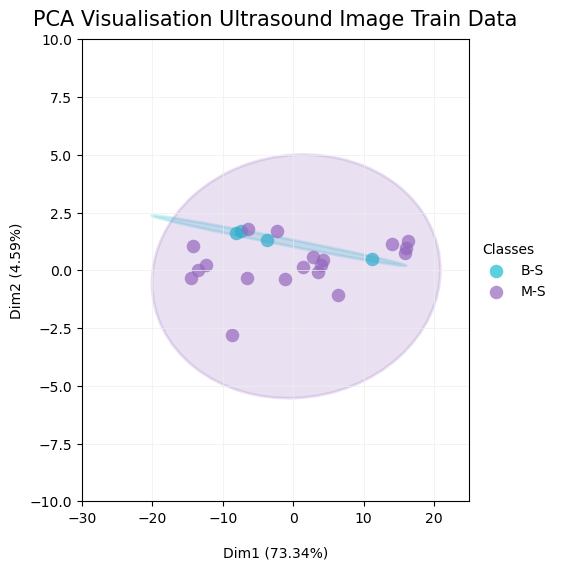

In [34]:
fig, ax = plt.subplots(figsize=(5, 6))
plt.rcParams['axes.spines.left'] = True
plt.rcParams['axes.spines.right'] = True
plt.rcParams['axes.spines.top'] = True
plt.rcParams['axes.spines.bottom'] = True

targets = ("B-S", "M-S")
colours = ("#17BECF", "#9467BD")

for target, colour in zip(targets, colours):

    # Sort data by class
    indicesToKeep = df_image_pca_class["SURGICAL"] == target
    xdata = df_image_pca_class.loc[indicesToKeep, "Principal Component 1"]
    ydata = df_image_pca_class.loc[indicesToKeep, "Principal Component 2"]

    # Get values to build the ellipse
    cov = np.cov(xdata, ydata)
    vals, vecs = eigsorted(cov)
    theta = np.degrees(np.arctan2(*vecs[:,0][::-1]))
    w, h = 2 * 2 * np.sqrt(vals)

    # Create the ellipse
    ell = Ellipse(xy=(np.mean(xdata), np.mean(ydata)),
                  width=w, height=h,
                  angle=theta, 
                  color=colour, linewidth=2, alpha=0.2)
    
    ell.set_facecolor(colour) # reference the colour for each factor (defined by lab)
    ax.add_artist(ell)
    ax.scatter(xdata, ydata,
               label=target, # use labels provided above
               c=colour, # use colors provided above
               lw=0, #remove the outer line of each point
               alpha=0.7, # increase transparency of points
               s=95) # increase the size of points
    
 # Add labels showing percentage of the variance explained
ax.set_title("PCA Visualisation Ultrasound Image Train Data", fontsize = 15, pad=10)
ax.set_xlabel('Dim1 ({:.2f}%)'.format(image_pca.explained_variance_ratio_[0]*100), fontsize=10, labelpad=15)
ax.set_xlim(-30,25)
ax.set_ylabel('Dim2 ({:.2f}%)'.format(image_pca.explained_variance_ratio_[1]*100), fontsize=10)
ax.set_ylim(-10,10)
ax.grid(which="major", color="#EEEEEE", linewidth=0.5)

plt.legend(bbox_to_anchor=(1, 0.5), loc="center left", frameon=False, title="Classes", alignment="left")
plt.show()

### RNA - Principal Component Analysis (2 Components)

In [35]:
# Seperating out the features
rna_features = rna_df.drop(["SURGICAL"], axis=1)

# Seperating out the target
rna_class = rna_df[["SURGICAL"]]

# Create PCA with 2 components
rna_pca = PCA(n_components=2)
rna_prinComps = rna_pca.fit_transform(rna_features)

# Create DataFrame
df_rna_princComps = pd.DataFrame(data=rna_prinComps, columns=["Principal Component 1", "Principal Component 2"])
df_rna_princComps

,Principal Component 1,Principal Component 2
0,-3.980590,-3.385155
1,-3.980585,-3.385157
2,0.957682,4.811622
3,9.796836,-3.893874
4,-3.980588,-3.385156
5,-3.980588,-3.385156
6,-3.980588,-3.385156
7,12.135703,0.829003
8,4.039188,-3.333138
9,-29.069475,0.535703


In [36]:
# Percentage explained by each component
print(rna_pca.explained_variance_ratio_)

[0.77227515 0.06854078]


In [37]:
# Final dataframe for plotting the data for class
df_rna_pca_class = pd.concat([df_rna_princComps, rna_class], axis=1)

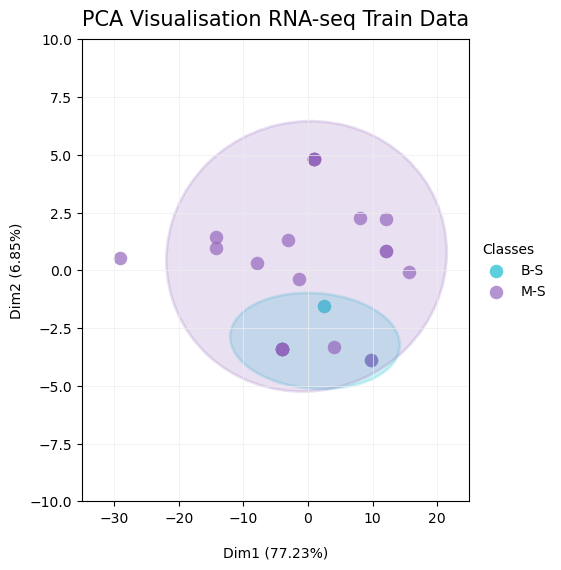

In [38]:
fig, ax = plt.subplots(figsize=(5, 6))
plt.rcParams['axes.spines.left'] = True
plt.rcParams['axes.spines.right'] = True
plt.rcParams['axes.spines.top'] = True
plt.rcParams['axes.spines.bottom'] = True

targets = ("B-S", "M-S")
colours = ("#17BECF", "#9467BD")


for target, colour in zip(targets, colours):

    # Sort data by class
    indicesToKeep = df_rna_pca_class["SURGICAL"] == target
    xdata = df_rna_pca_class.loc[indicesToKeep, "Principal Component 1"]
    ydata = df_rna_pca_class.loc[indicesToKeep, "Principal Component 2"]

    # Get values to build the ellipse
    cov = np.cov(xdata, ydata)
    vals, vecs = eigsorted(cov)
    theta = np.degrees(np.arctan2(*vecs[:,0][::-1]))
    w, h = 2 * 2 * np.sqrt(vals)

    # Create the ellipse
    ell = Ellipse(xy=(np.mean(xdata), np.mean(ydata)),
                  width=w, height=h,
                  angle=theta, 
                  color=colour, linewidth=2, alpha=0.2)
    
    ell.set_facecolor(colour) # reference the colour for each factor (defined by lab)
    ax.add_artist(ell)
    ax.scatter(xdata, ydata,
               label=target, # use labels provided above
               c=colour, # use colors provided above
               lw=0, #remove the outer line of each point
               alpha=0.7, # increase transparency of points
               s=95) # increase the size of points
    
 # Add labels showing percentage of the variance explained
ax.set_title("PCA Visualisation RNA-seq Train Data", fontsize = 15, pad=10)
ax.set_xlabel('Dim1 ({:.2f}%)'.format(rna_pca.explained_variance_ratio_[0]*100), fontsize=10, labelpad=15)
ax.set_xlim(-35,25)
ax.set_ylabel('Dim2 ({:.2f}%)'.format(rna_pca.explained_variance_ratio_[1]*100), fontsize=10)
ax.set_ylim(-10,10)
ax.grid(which="major", color="#EEEEEE", linewidth=0.5)

plt.legend(bbox_to_anchor=(1, 0.5), loc="center left", frameon=False, title="Classes", alignment="left")
plt.show()

## Spearman Rho Correlation Coefficient

In [39]:
# Seperating out the features
rna_all = rna_train
# Seperating out the target
surg_df = pd.DataFrame({"SURGICAL": surg_train})
rna_class_cat = pd.Categorical(surg_df["SURGICAL"].astype("category")).codes

In [40]:
thresholds = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

def spearman_thresh_function(features, target, thresholds):
    threshold_list = []
    num_features = []

    column_names = features.columns.tolist()

    for threshold in thresholds:
        threshold_list.append(threshold)
        count = 0
        for column in column_names:
            corr, pval = spearmanr(features[column], target)
            if (corr > threshold):
                count += 1
        num_features.append(count)

    return threshold_list, num_features

In [41]:
rna_thresholds, rna_threshold_counts = spearman_thresh_function(rna_all, rna_class_cat, thresholds)

/tmp/ipykernel_41446/2888998525.py:13: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, pval = spearmanr(features[column], target)


In [42]:
threshold_df = pd.DataFrame(
    {
        "Threshold": map(str, rna_thresholds),
        "Feature Count": rna_threshold_counts
    }
)

threshold_df

,Threshold,Feature Count
0,0.1,19463
1,0.2,10440
2,0.3,5435
3,0.4,2266
4,0.5,679
5,0.6,27
6,0.7,0
7,0.8,0
8,0.9,0


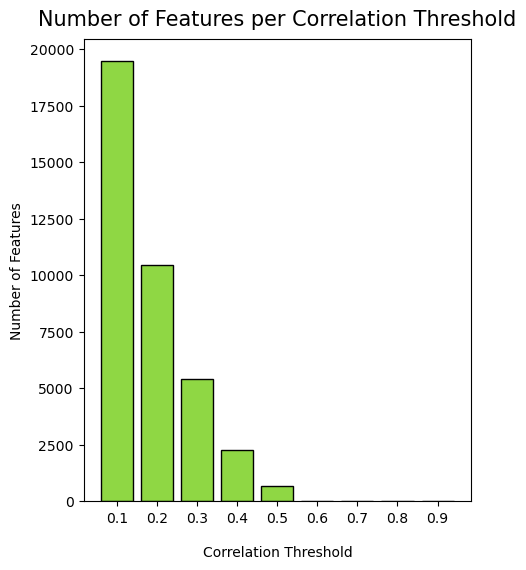

In [43]:
fig,ax = plt.subplots(figsize=(5, 6)) 
ax.bar(threshold_df["Threshold"], threshold_df["Feature Count"], color="#8FD744FF", edgecolor="black")
ax.set_title("Number of Features per Correlation Threshold", fontsize = 15, pad=10)
ax.set_xlabel("Correlation Threshold", fontsize=10, labelpad=15)
ax.set_ylabel("Number of Features", fontsize=10)
plt.show()

In [44]:
def spearman_df_function(features, target, threshold):
    feature_names = []
    feature_correlations = []
    
    column_names = features.columns.tolist()

    for column in column_names:
        corr, pval = spearmanr(features[column], target)
        if (corr > threshold):
            feature_names.append(column)
            feature_correlations.append(corr)

    return feature_names, feature_correlations

In [45]:
rna_feature_names, rna_feature_correlations = spearman_df_function(rna_all, rna_class_cat, 0.5)

/tmp/ipykernel_41446/189007027.py:8: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, pval = spearmanr(features[column], target)


In [46]:
spearman_df = pd.DataFrame(
    {
        "Features": rna_feature_names,
        "Correlations": rna_feature_correlations
    }
)

spearman_df

,Features,Correlations
0,ENSG00000189280,0.570408
1,ENSG00000092853,0.533462
2,ENSG00000134697,0.565301
3,ENSG00000214114,0.565301
4,ENSG00000155761,0.549269
...,...,...
674,ENSG00000099958,0.573501
675,ENSG00000128165,0.508882
676,ENSG00000241484,0.526297
677,ENSG00000142197,0.500695


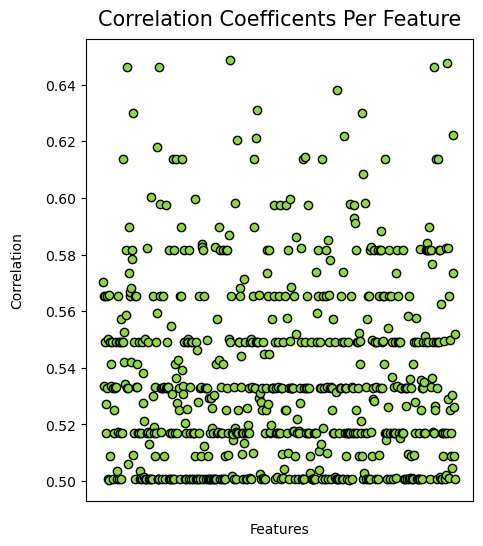

In [47]:
fig,ax = plt.subplots(figsize=(5, 6)) 
ax.scatter(spearman_df["Features"], spearman_df["Correlations"], color="#8FD744FF", edgecolors="black")
ax.set_title("Correlation Coefficents Per Feature", fontsize = 15, pad=10)
ax.set_xlabel("Features", fontsize=10, labelpad=15)
ax.set_ylabel("Correlation", fontsize=10, labelpad=15)

plt.tick_params(bottom=False, labelbottom=False)
plt.show()

In [48]:
# Store spearman features
spearman_rna = spearman_df["Features"].to_list()

In [49]:
# Seperating out the features
rna_spear = rna_train
# Only keep the top features
rna_spear = rna_spear.loc[:, rna_spear.columns.isin(spearman_rna)]

### Load Data

In [50]:
# Create dataset with image_directory passed in
data = RNACustomDataset(rna_spear, img_train, image_directory, transform=train_transform_albu, transform_type="albu")

In [51]:
batch_size = 24
train_loader = DataLoader(data, batch_size=batch_size, shuffle=False, num_workers=0)

### Create Embedding Master DataFrames

In [52]:
with torch.no_grad():
    for rna_batch, image_batch, labels in train_loader:
        rna_batch, image_batch, labels = rna_batch.to(device), image_batch.to(device), labels.to(device)
        # Forward pass through both encoders
        rna_embeddings, image_embeddings = model(rna_batch, image_batch)

RuntimeError: mat1 and mat2 shapes cannot be multiplied (24x679 and 63187x1024)

In [ ]:
rna_embeddings.size()

In [ ]:
image_embeddings.size()

In [ ]:
# Scaler for embeddings 
scaler = StandardScaler()

In [ ]:
# RNA DataFrame
rna_df = pd.DataFrame(scaler.fit_transform(rna_embeddings.cpu().numpy()))
rna_df.insert(0, "SURGICAL", surg_train)

In [ ]:
rna_df

In [ ]:
# Image DataFrame
image_df = pd.DataFrame(scaler.fit_transform(image_embeddings.cpu().numpy()))
image_df.insert(0, "SURGICAL", surg_train)

In [ ]:
image_df

### Image - Principal Component Analysis (2 Components)

In [ ]:
# Seperating out the features
image_features = image_df.drop(["SURGICAL"], axis=1)

# Seperating out the target
image_class = image_df[["SURGICAL"]]

# Create PCA with 2 components
image_pca = PCA(n_components=2)
image_prinComps = image_pca.fit_transform(image_features)

# Create DataFrame
df_image_princComps = pd.DataFrame(data=image_prinComps, columns=["Principal Component 1", "Principal Component 2"])
df_image_princComps

In [ ]:
# Percentage explained by each component
print(image_pca.explained_variance_ratio_)

In [ ]:
# Final dataframe for plotting the data for class
df_image_pca_class = pd.concat([df_image_princComps, image_class], axis=1)

In [ ]:
fig, ax = plt.subplots(figsize=(5, 6))
plt.rcParams['axes.spines.left'] = True
plt.rcParams['axes.spines.right'] = True
plt.rcParams['axes.spines.top'] = True
plt.rcParams['axes.spines.bottom'] = True

targets = ("B-S", "M-S")
colours = ("#17BECF", "#9467BD")

for target, colour in zip(targets, colours):

    # Sort data by class
    indicesToKeep = df_image_pca_class["SURGICAL"] == target
    xdata = df_image_pca_class.loc[indicesToKeep, "Principal Component 1"]
    ydata = df_image_pca_class.loc[indicesToKeep, "Principal Component 2"]

    # Get values to build the ellipse
    cov = np.cov(xdata, ydata)
    vals, vecs = eigsorted(cov)
    theta = np.degrees(np.arctan2(*vecs[:,0][::-1]))
    w, h = 2 * 2 * np.sqrt(vals)

    # Create the ellipse
    ell = Ellipse(xy=(np.mean(xdata), np.mean(ydata)),
                  width=w, height=h,
                  angle=theta, 
                  color=colour, linewidth=2, alpha=0.2)
    
    ell.set_facecolor(colour) # reference the colour for each factor (defined by lab)
    ax.add_artist(ell)
    ax.scatter(xdata, ydata,
               label=target, # use labels provided above
               c=colour, # use colors provided above
               lw=0, #remove the outer line of each point
               alpha=0.7, # increase transparency of points
               s=95) # increase the size of points
    
 # Add labels showing percentage of the variance explained
ax.set_title("PCA Visualisation Ultrasound Image Train Data v2", fontsize = 15, pad=10)
ax.set_xlabel('Dim1 ({:.2f}%)'.format(image_pca.explained_variance_ratio_[0]*100), fontsize=10, labelpad=15)
ax.set_xlim(-30,25)
ax.set_ylabel('Dim2 ({:.2f}%)'.format(image_pca.explained_variance_ratio_[1]*100), fontsize=10)
ax.set_ylim(-10,10)
ax.grid(which="major", color="#EEEEEE", linewidth=0.5)

plt.legend(bbox_to_anchor=(1, 0.5), loc="center left", frameon=False, title="Classes", alignment="left")
plt.show()

### RNA - Principal Component Analysis (2 Components)

In [ ]:
# Seperating out the features
rna_features = rna_df.drop(["SURGICAL"], axis=1)

# Seperating out the target
rna_class = rna_df[["SURGICAL"]]

# Create PCA with 2 components
rna_pca = PCA(n_components=2)
rna_prinComps = rna_pca.fit_transform(rna_features)

# Create DataFrame
df_rna_princComps = pd.DataFrame(data=rna_prinComps, columns=["Principal Component 1", "Principal Component 2"])
df_rna_princComps

In [ ]:
# Percentage explained by each component
print(rna_pca.explained_variance_ratio_)

In [ ]:
# Final dataframe for plotting the data for class
df_rna_pca_class = pd.concat([df_rna_princComps, rna_class], axis=1)

In [ ]:
fig, ax = plt.subplots(figsize=(5, 6))
plt.rcParams['axes.spines.left'] = True
plt.rcParams['axes.spines.right'] = True
plt.rcParams['axes.spines.top'] = True
plt.rcParams['axes.spines.bottom'] = True

targets = ("B-S", "M-S")
colours = ("#17BECF", "#9467BD")


for target, colour in zip(targets, colours):

    # Sort data by class
    indicesToKeep = df_rna_pca_class["SURGICAL"] == target
    xdata = df_rna_pca_class.loc[indicesToKeep, "Principal Component 1"]
    ydata = df_rna_pca_class.loc[indicesToKeep, "Principal Component 2"]

    # Get values to build the ellipse
    cov = np.cov(xdata, ydata)
    vals, vecs = eigsorted(cov)
    theta = np.degrees(np.arctan2(*vecs[:,0][::-1]))
    w, h = 2 * 2 * np.sqrt(vals)

    # Create the ellipse
    ell = Ellipse(xy=(np.mean(xdata), np.mean(ydata)),
                  width=w, height=h,
                  angle=theta, 
                  color=colour, linewidth=2, alpha=0.2)
    
    ell.set_facecolor(colour) # reference the colour for each factor (defined by lab)
    ax.add_artist(ell)
    ax.scatter(xdata, ydata,
               label=target, # use labels provided above
               c=colour, # use colors provided above
               lw=0, #remove the outer line of each point
               alpha=0.7, # increase transparency of points
               s=95) # increase the size of points
    
 # Add labels showing percentage of the variance explained
ax.set_title("PCA Visualisation RNA-seq Train Data (Spearman's Rho - $ > 0.5$)", fontsize = 15, pad=10)
ax.set_xlabel('Dim1 ({:.2f}%)'.format(rna_pca.explained_variance_ratio_[0]*100), fontsize=10, labelpad=15)
ax.set_xlim(-35,25)
ax.set_ylabel('Dim2 ({:.2f}%)'.format(rna_pca.explained_variance_ratio_[1]*100), fontsize=10)
ax.set_ylim(-10,10)
ax.grid(which="major", color="#EEEEEE", linewidth=0.5)

plt.legend(bbox_to_anchor=(1, 0.5), loc="center left", frameon=False, title="Classes", alignment="left")
plt.show()